Feature_Selection

In [2]:
#Feature selection in machine learning is the process of choosing the most relevant input variables for a model, and it’s crucial because it improves accuracy, reduces overfitting, speeds up training, and makes models easier to interpret. Without it, models risk becoming slow, complex, and prone to poor generalization.

In [3]:
import pandas as pd
import numpy as np

In [4]:
data=pd.read_csv('./diabetes.csv')

In [5]:
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [6]:
data.shape

(768, 9)

In [7]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
x=data.drop('Outcome',axis=1)
y=data['Outcome']

In [9]:
# there are four types of methods in feature selection Filter Method, Wrapper Method ,RECUSIVE FEATURE ELIMINATION, Embedded Method

FILTER METHOD

In [10]:
# The filter method evaluates features independently of any machine learning algorithm. It uses statistical measures to score each feature's relevance to the target variable, then selects the top-scoring features before training begins.

In [11]:
# The Core Reasons
# 1. Curse of Dimensionality
# When you have too many features, your data becomes sparse in high-dimensional space. Imagine trying to find patterns in a dataset with 1000 features but only 500 samples—there's more dimensions than data points! This leads to:

In [12]:
# For Classification:

# Chi-Square Test (χ²): Measures dependency between categorical features and target
# ANOVA F-test: Tests if means differ across classes (numerical features)
# Mutual Information: Measures how much knowing one variable reduces uncertainty about another
# Information Gain: Reduction in entropy when the feature is used

# For Regression:

# Pearson Correlation: Linear relationship between feature and target
# Spearman Correlation: Monotonic (not necessarily linear) relationships
# Mutual Information: Works for non-linear relationships too

In [14]:
data.columns.value_counts().sum()

np.int64(9)

In [15]:
#chi-square test 
from  sklearn.feature_selection import chi2
from sklearn.feature_selection import SelectKBest
k_best=SelectKBest(score_func=chi2,k=4)
first_4=k_best.fit(x,y)
chi_score=chi2(x,y)

In [16]:
chi_score

(array([ 111.51969064, 1411.88704064,   17.60537322,   53.10803984,
        2175.56527292,  127.66934333,    5.39268155,  181.30368904]),
 array([4.55261043e-026, 5.48728628e-309, 2.71819252e-005, 3.15697650e-013,
        0.00000000e+000, 1.32590849e-029, 2.02213728e-002, 2.51638830e-041]))

In [17]:
# What is a P-value?
# The p-value tells you: "What's the probability that this result happened by pure random chance?"
# Low p-value (< 0.05) = Result is statistically significant = Unlikely to be random chance
# High p-value (> 0.05) = Result might just be random luck = Not significant

<Axes: >

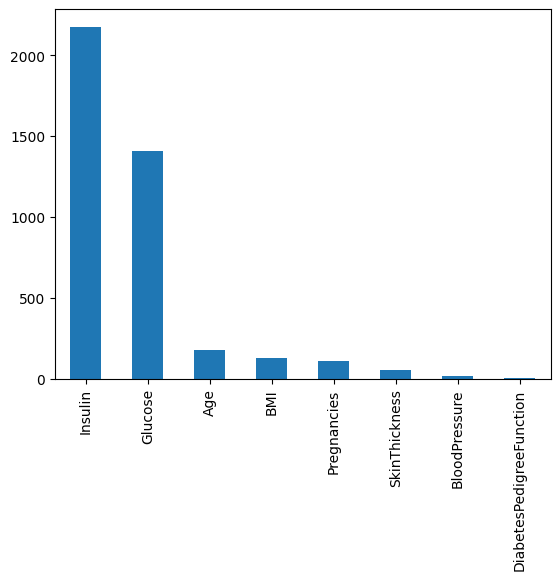

In [25]:
import matplotlib.pyplot as plt
#higher the chi value, higher the importance 
series_chi=pd.Series(chi_score[0],index=x.columns).sort_values(ascending=False)
series_chi.plot.bar()

<Axes: >

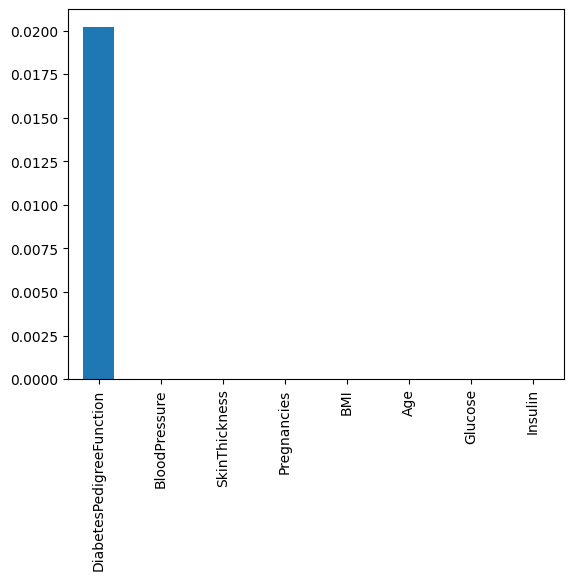

In [26]:
#higher the p value low importance 
import matplotlib.pyplot as plt 
series_chi=pd.Series(chi_score[1],index=x.columns).sort_values(ascending=False)
series_chi.plot.bar()


In [27]:
# in P value which is highest have to low relation to the target varible

 Wrapper Method 

In [28]:
#RECUSIVE FEATURE ELIMINATION
# Wrapper methods in feature engineering are feature selection techniques that test different subsets of features by actually training a machine learning model and keeping the set that gives the best performance. In simple terms: they “wrap” around the model, trying combinations of features until they find the most useful ones

In [29]:
# Step 1: Train model with ALL features
#         ↓
# Step 2: Rank features by importance
#         ↓
# Step 3: Remove the WORST feature
#         ↓
# Step 4: Train model again with remaining features
#         ↓
# Step 5: Repeat steps 2-4 until you have K features left
#         ↓
# Step 6: Return the K best features

In [31]:
# example
# Imagine you have 10 features in your dataset:
#Wrapper methods will try subsets like {F1, F2}, {F1, F3, F4}, {F2, F5, F6}, etc.
#For each subset, they train the model and check accuracy.
#Finally, they keep the subset that gives the highest accuracy. 

In [32]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()


In [33]:
import warnings
warnings.filterwarnings('ignore')

In [34]:
recusive=RFE(lr)
feature=recusive.fit(x,y)
print(f'number of feature:{feature.n_features_}') #This tells you how many features were selected after the feature selection process.
print(f'selecterd feature are:{feature.support_}') # This is a Boolean mask (True/False array) showing which features were selected.True → feature is selected ,False → feature is not selected
print(f'feature ranking as follow:{feature.ranking_}')# This gives the ranking of all features.


number of feature:4
selecterd feature are:[ True  True False False False  True  True False]
feature ranking as follow:[1 1 3 4 5 1 1 2]


In [35]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
#Position 1 → Pregnancies 
#Position 2 → Glucose 
#Position 6 → BMI 
#Position 7 → DiabetesPedigreeFunction 
#So the selected features are:['Pregnancies', 'Glucose', 'BMI', 'DiabetesPedigreeFunction']


 Embedded Method

In [36]:
# Embedded methods perform feature selection automatically DURING model training as part of the learning algorithm itself.
# Main Embedded Methods
# 1. Lasso Regression (L1 Regularisation)

# Automatically shrinks weak feature coefficients to ZERO
# Features with coefficient = 0 are automatically eliminated

# 2. Ridge Regression (L2 Regularisation)

# Reduces feature coefficients but doesn't eliminate them completely
# Less aggressive than Lasso

# 3. Tree-based Methods (Random Forest, XGBoost, etc.)

# Calculate feature importance during training
# Can select top features based on importance scores

# 4. Elastic Net

# Combination of Lasso + Ridge
# Balances feature elimination and coefficient reduction

In [ ]:
# Traditional Training:
# Train model → Use all features → Done
# Embedded Method:
# Train model → Penalize weak features → 
# Weak features get coefficient = 0 → 
# Only important features remain → Done

In [38]:
#Aspect               | Filter                  | Wrapper                   | Embedded
#---------------------|-------------------------|---------------------------|-------------------------
#When                 | Before training         | During selection process  | During model training
#Model needed?        | ❌ No                   | ✅ Yes                   | ✅ Yes
#Speed ⚡⚡⚡       | Fastest 🐢              | Slowest                   | Fast–Medium
#Accuracy             | Good                    | Best                      | Very Good
#Feature interactions | Ignores ✅              | Considers ✅              | Considers ✅
#Examples             | Chi-square, F-test      | RFE, Sequential Selection | Lasso, Random Forest
#Overfitting          | Low                     | High                      | Medium
#Scalability          | Best for 1000+ features | Best for <100 features    | Good for any size
